<p style="
    font-style: italic;
    font-weight: bold;
    background-color: #FFFF00;
    color: green;
    text-align: center;
    font-size: 30px;
    margin: 10px 0;
    padding: 10px;
    border: 4px solid green;
    border-radius: 30px;
    ">
    Smart Manufacturing Downtime Risk Classification
</p>

<p style="font-weight:bold">STEP 1</p><p style="color:green;font-style:italic">The objective of this project is to develop a machine learning classification model using the AI4I Predictive Maintenance Dataset to predict machine failure (downtime risk) based on operational and sensor data. The model will identify high-risk conditions in real time, enabling proactive maintenance and optimized production scheduling. Additionally, Explainable AI techniques will be applied to interpret the key factors influencing downtime risk.</p>

<p style="font-weight:bold">STEP 2</p><p style="color:green;font-style:italic">Collect production and downtime logs.</p>

In [1]:
import numpy as np
import pandas as pd 
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

import shap
import joblib

In [2]:
df=pd.read_csv("data1.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


<p style="color:green;font-style:italic">Production Logs</p>

In [3]:
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]',
            'Tool wear [min]', 'Type']
features

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Type']

<p style="color:green;font-style:italic">Downtime Logs</p>

In [4]:
target = 'Machine failure'
df = df[features + [target]]

<p style="font-weight:bold">STEP 3</p><p style="color:green;font-style:italic">Analyze failure frequency patterns.</p>

Failure Distribution:
 Machine failure
0    9661
1     339
Name: count, dtype: int64


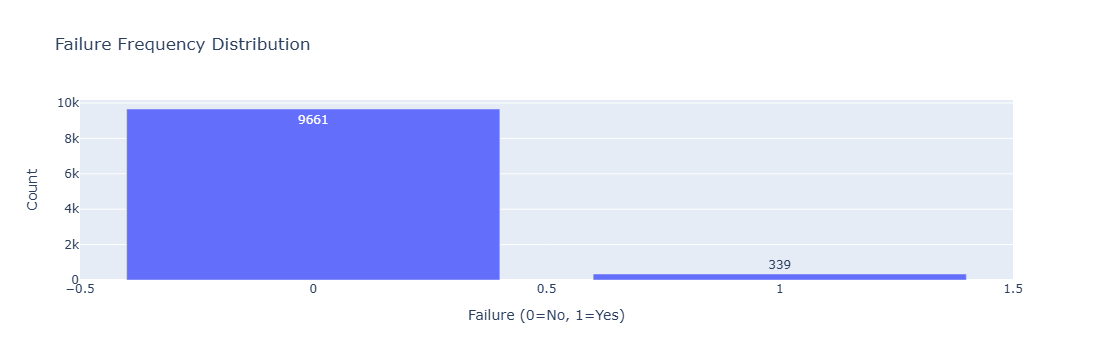

In [5]:
print("Failure Distribution:\n", df[target].value_counts())

fig = px.bar(
    df[target].value_counts().reset_index(),
    x=target,           
    y='count',
    labels={target: 'Failure (0=No, 1=Yes)', 'count': 'Count'},
    title="Failure Frequency Distribution",text_auto=True
)
fig.show()

<p style="font-weight:bold">STEP 4</p><p style="color:green;font-style:italic">Clean operational datasets.</p>

In [6]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates if any
df = df.drop_duplicates()


Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Type                       0
Machine failure            0
dtype: int64


In [7]:
df.isnull().sum()

Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Type                       0
Machine failure            0
dtype: int64

In [8]:
df=df.dropna()

<p style="font-weight:bold">STEP 5</p><p style="color:green;font-style:italic">Perform downtime trend analysis.</p>

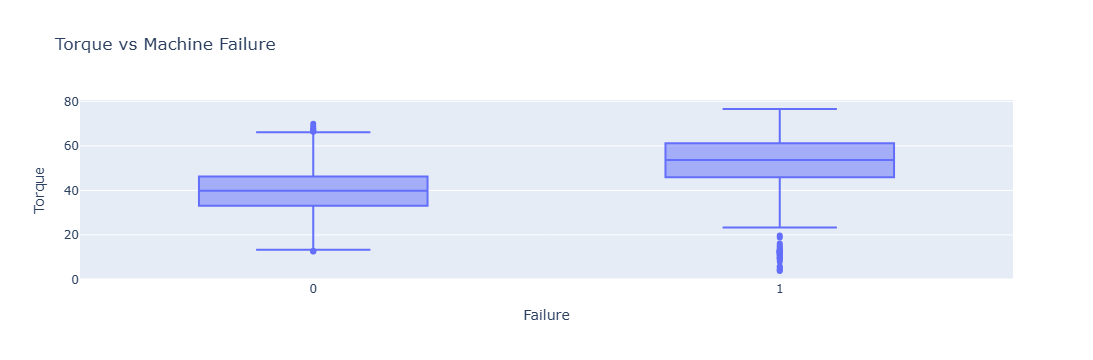

In [9]:
# Analyze relationship with features
fig = px.box(
    df,
    x=target,
    y='Torque [Nm]',
    title="Torque vs Machine Failure",
    labels={target: 'Failure', 'Torque [Nm]': 'Torque'}
)
fig.show()


<p style="font-weight:bold">STEP 6</p><p style="color:green;font-style:italic">Engineer time and workload features.</p>

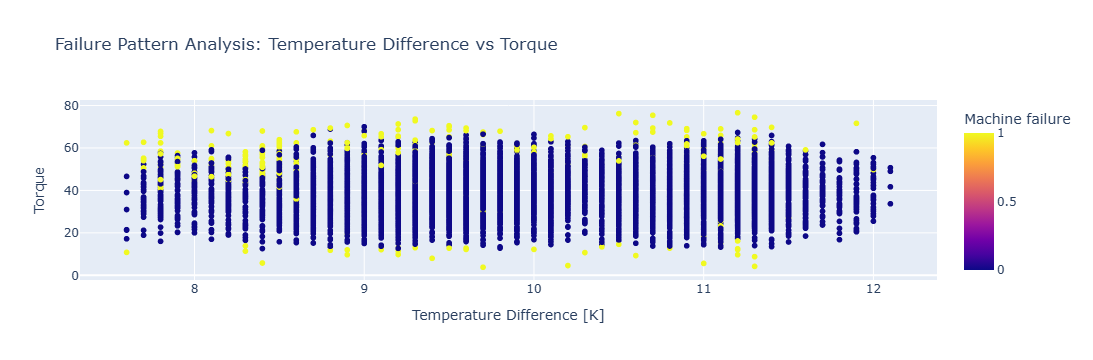

In [10]:
# Create temperature difference feature
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
fig = px.scatter(
    df, 
    x='Temp_diff', 
    y='Torque [Nm]', 
    color=target, 
    title="Failure Pattern Analysis: Temperature Difference vs Torque",
    labels={'Temp_diff': 'Temperature Difference [K]', 'Torque [Nm]': 'Torque'},
    color_discrete_sequence=px.colors.qualitative.Bold)

fig.show()

# Create load feature
df['Load'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

<p style="font-weight:bold">STEP 7</p><p style="color:green;font-style:italic">Encode categorical production factors.</p>

In [11]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
df['Machine failure'] = df['Machine failure'].astype(int)

<p style="font-weight:bold">STEP 8</p><p style="color:green;font-style:italic">Split data into training/testing sets</p>

In [12]:
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<p style="font-weight:bold">STEP 9</p><p style="color:green;font-style:italic">Train decision tree classifier.</p>

In [13]:
model = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced',
    min_samples_leaf=15,
    random_state=42,
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

<p style="font-weight:bold">STEP 10</p><p style="color:green;font-style:italic">Evaluate misclassification risk</p>

Confusion Matrix:
 [[1839   93]
 [   6   62]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97      1932
           1       0.40      0.91      0.56        68

    accuracy                           0.95      2000
   macro avg       0.70      0.93      0.76      2000
weighted avg       0.98      0.95      0.96      2000



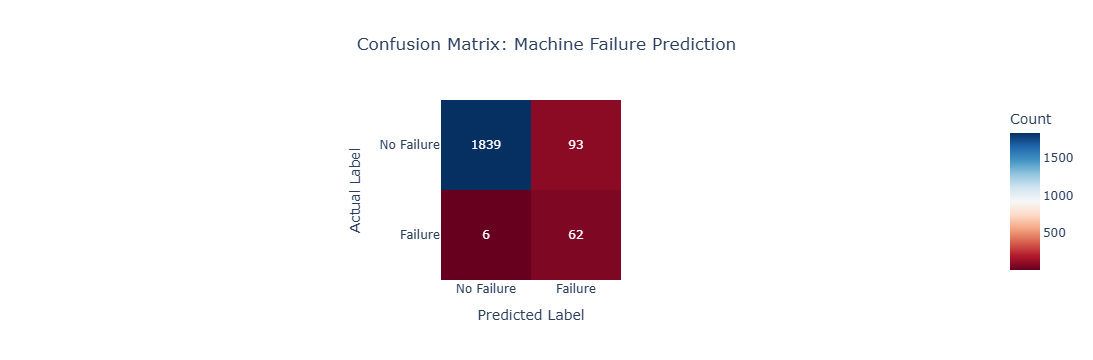

In [14]:
y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
labels = ['No Failure', 'Failure']

fig = px.imshow(
    cm,
    x=labels,
    y=labels,
    text_auto=True, 
    color_continuous_scale='rdbu',
    labels=dict(x="Predicted Label", y="Actual Label", color="Count"),
    title="Confusion Matrix: Machine Failure Prediction"
)

fig.update_layout(title_x=0.5)
fig.show()

<p style="font-weight:bold">STEP 11</p><p style="color:green;font-style:italic">Interpret downtime drivers ( Using Explainable AI - SHAP)</p>

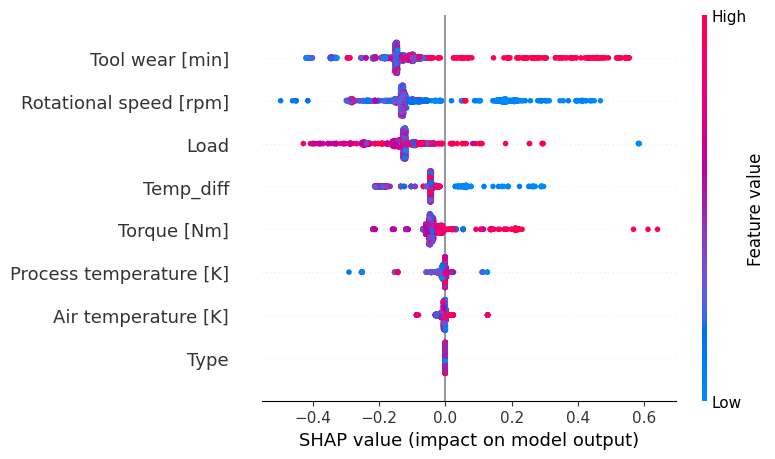

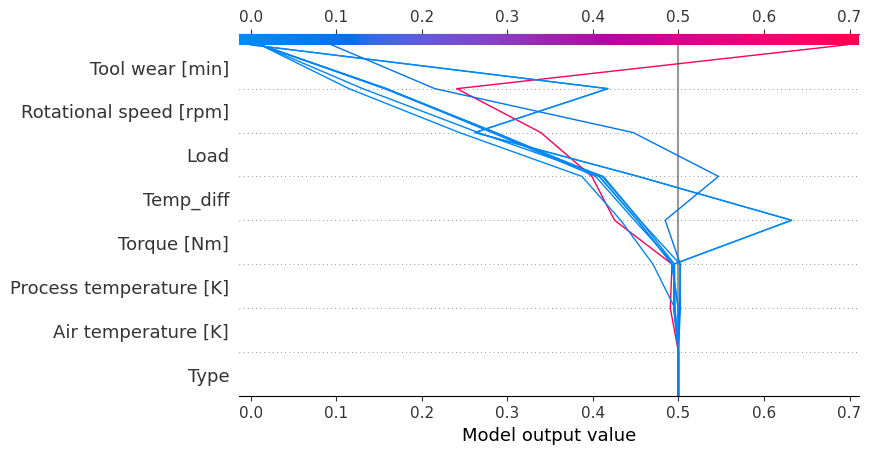

In [25]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:,:,1], X_test)

# Select the first 10 failure cases to see their "paths" to downtime
shap.decision_plot(
    explainer.expected_value[1], 
    shap_values[:10, :, 1], 
    X_test.iloc[:10, :]
)


<p style="font-weight:bold">STEP 12</p><p style="color:green;font-style:italic">Create scheduling improvement logic.</p>

In [26]:
def scheduling_decision(prediction):
    if prediction == 1:
        return "High Risk -> Schedule Maintenance"
    else:
        return "Low Risk -> Continue Production"
print(scheduling_decision(y_pred[0]))


Low Risk -> Continue Production


<p style="font-weight:bold">STEP 13</p><p style="color:green;font-style:italic">Save trained model.</p>

In [27]:
joblib.dump(model, "downtime_model.pkl")


['downtime_model.pkl']

<p style="font-weight:bold">STEP 14</p><p style="color:green;font-style:italic">Develop Streamlit operational dashboard.</p>

In [28]:
streamlit_code=r"""import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import shap

# =========================
# CONFIG
# =========================
st.set_page_config(page_title="Downtime Risk Dashboard", layout="wide")

# =========================
# LOAD DATA (FIXED)
# =========================
@st.cache_data
def load_data():
    df = pd.read_csv("data1.csv")

    # Drop unnecessary columns
    df = df.drop(columns=['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], errors='ignore')

    # 🔥 FIX 1: Encode Type properly (PERMANENT FIX)
    df['Type'] = df['Type'].replace({'L': 0, 'M': 1, 'H': 2})
    df['Type'] = pd.to_numeric(df['Type'], errors='coerce')
    df['Type_label'] = df['Type'].map({0: 'Low', 1: 'Medium', 2: 'High'})

    # 🔥 FIX 2: Feature Engineering
    df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
    df['Load'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

    return df

# =========================
# LOAD MODEL
# =========================
@st.cache_resource
def load_model():
    return joblib.load("downtime_model.pkl")

df = load_data()
model = load_model()

# =========================
# FEATURE LIST (MUST MATCH TRAINING)
# =========================
feature_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Type',
    'Temp_diff',
    'Load'
]

# =========================
# TITLE
# =========================
st.title("🏭 Smart Manufacturing Downtime Risk Dashboard")

# =========================
# SIDEBAR INPUTS
# =========================
st.sidebar.header("🔧 Machine Inputs")

air_temp = st.sidebar.slider("Air Temperature", float(df['Air temperature [K]'].min()), float(df['Air temperature [K]'].max()))
process_temp = st.sidebar.slider("Process Temperature", float(df['Process temperature [K]'].min()), float(df['Process temperature [K]'].max()))
rpm = st.sidebar.slider("Rotational Speed", int(df['Rotational speed [rpm]'].min()), int(df['Rotational speed [rpm]'].max()))
torque = st.sidebar.slider("Torque", float(df['Torque [Nm]'].min()), float(df['Torque [Nm]'].max()))
tool_wear = st.sidebar.slider("Tool Wear", int(df['Tool wear [min]'].min()), int(df['Tool wear [min]'].max()))

type_map = {'L': 0, 'M': 1, 'H': 2}
type_input = st.sidebar.selectbox("Machine Type", list(type_map.keys()))
machine_type = type_map[type_input]

selected_types = st.sidebar.multiselect(
    "Machine Type Filter",
    options=list(type_map.keys()),
    default=list(type_map.keys())
)
selected_failure = st.sidebar.multiselect(
    "Failure status",
    options=[0, 1],
    default=[0, 1],
    format_func=lambda x: "Failure" if x == 1 else "No Failure"
)
selected_palette = st.sidebar.selectbox(
    "Chart color palette",
    options=["blues", "viridis", "matter", "plasma"],
    index=0
)
shap_sample_size = st.sidebar.slider(
    "SHAP sample size",
    min_value=50,
    max_value=min(500, len(df)),
    value=min(200, len(df)),
    step=50
)

# =========================
# INPUT FEATURE CREATION
# =========================
temp_diff = process_temp - air_temp
load = torque * rpm

input_df = pd.DataFrame([[
    air_temp, process_temp, rpm, torque,
    tool_wear, machine_type, temp_diff, load
]], columns=feature_cols)

filtered_df = df[
    df['Type'].isin([type_map[t] for t in selected_types]) &
    df['Machine failure'].isin(selected_failure)
].copy()
if filtered_df.empty:
    st.sidebar.warning("No data matches the filter. Showing full dataset.")
    filtered_df = df.copy()

filtered_df['Type_label'] = filtered_df['Type_label'].fillna('Unknown')
filtered_df['Failure_label'] = filtered_df['Machine failure'].map({0: 'No Failure', 1: 'Failure'})

predicted_proba = model.predict_proba(filtered_df[feature_cols])[:, 1] if len(filtered_df) > 0 else np.array([0])
filter_failure_rate = filtered_df['Machine failure'].mean() * 100 if len(filtered_df) > 0 else 0
avg_predicted_risk = predicted_proba.mean() * 100 if len(filtered_df) > 0 else 0

# =========================
# REAL-TIME PREDICTION
# =========================
st.subheader("🔮 Real-Time Downtime Prediction")

prediction = model.predict(input_df)[0]
prob = model.predict_proba(input_df)[0][1]

col1, col2 = st.columns(2)

with col1:
    if prediction == 1:
        st.error("⚠ High Downtime Risk")
    else:
        st.success("✅ Low Downtime Risk")

with col2:
    st.metric("Failure Probability", f"{prob:.2f}")

prediction_tab, insights_tab, explain_tab = st.tabs([
    "Live Prediction",
    "Interactive Insights",
    "Explainability"
])

with prediction_tab:
    st.markdown("### Live Prediction Metrics")
    metric1, metric2, metric3 = st.columns(3)
    metric1.metric("Current Prediction", "Failure" if prediction == 1 else "No Failure")
    metric2.metric("Current Risk", f"{prob:.1f}%")
    metric3.metric("Risk Level", "High" if prob > 0.7 else "Medium" if prob > 0.3 else "Low")

    fig_gauge = go.Figure(go.Indicator(
        mode="gauge+number",
        value=prob * 100,
        number={'suffix': '%', 'font': {'size': 44, 'color': 'white'}},
        title={'text': "Live Downtime Risk", 'font': {'size': 24, 'color': 'white'}},
        gauge={
            'shape': 'angular',
            'axis': {'range': [0, 100], 'tickwidth': 2, 'tickcolor': 'white'},
            'bar': {'color': '#00E676'},
            'steps': [
                {'range': [0, 30], 'color': '#0E7E34'},
                {'range': [30, 70], 'color': '#F5B400'},
                {'range': [70, 100], 'color': '#F35B04'},
            ],
            'threshold': {
                'line': {'color': 'red', 'width': 4},
                'thickness': 0.75,
                'value': prob * 100
            }
        }
    ))
    fig_gauge.update_layout(
        template='plotly_dark',
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin={'t': 10, 'b': 10, 'l': 10, 'r': 10}
    )
    st.plotly_chart(fig_gauge, use_container_width=True)

# =========================
# SCHEDULING
# =========================
st.subheader("📅 Scheduling Recommendation")

if prediction == 1:
    st.error("🚨 Schedule Maintenance Immediately")
else:
    st.success("✅ Continue Production")

# =========================
# DATA INSIGHTS
# =========================
with insights_tab:
    st.subheader("📊 Interactive Data Insights")
    st.markdown("Use the filters on the left to explore the dataset in real time.")

    st.markdown("### Current Filters")
    col_a, col_b = st.columns(2)
    with col_a:
        st.write(f"**Machine Types:** {', '.join(selected_types) if selected_types else 'None'}")
    with col_b:
        st.write(f"**Failure Status:** {', '.join(['Failure' if x == 1 else 'No Failure' for x in selected_failure]) if selected_failure else 'None'}")

    st.info(f"Filtered dataset has {len(filtered_df)} records matching the current filters.")

    st.markdown("### Dataset Metrics")
    metric1, metric2, metric3 = st.columns(3)
    metric1.metric("Filtered records", len(filtered_df))
    metric2.metric("Filtered failure rate", f"{filter_failure_rate:.1f}%")
    metric3.metric("Avg dataset risk", f"{avg_predicted_risk:.1f}%")

    chart_cols = st.columns(2)
    with chart_cols[0]:
        fig1 = px.histogram(
            filtered_df,
            x='Failure_label',
            color='Type_label',
            barmode='group',
            title="Failure Distribution by Machine Type",
            template='plotly_dark',
            color_discrete_sequence=px.colors.qualitative.Plotly
        )
        fig1.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig1, use_container_width=True)

    with chart_cols[1]:
        fig2 = px.box(
            filtered_df,
            x='Failure_label',
            y='Torque [Nm]',
            color='Failure_label',
            title="Torque by Failure Status",
            template='plotly_dark',
            color_discrete_sequence=['#00cc96', '#ff6361']
        )
        fig2.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig2, use_container_width=True)

    st.markdown("---")
    st.markdown("### Custom scatter explorer")
    x_axis = st.selectbox("X axis feature", feature_cols, index=0)
    y_axis = st.selectbox("Y axis feature", feature_cols, index=3)
    fig_scatter = px.scatter(
        filtered_df,
        x=x_axis,
        y=y_axis,
        color='Failure_label',
        title=f"{y_axis} vs {x_axis}",
        template='plotly_dark',
        hover_data=feature_cols,
        color_discrete_sequence=['#636EFA', '#EF553B']
    )
    fig_scatter.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
    st.plotly_chart(fig_scatter, use_container_width=True)

    st.markdown("---")
    st.subheader("📈 Feature Correlation")
    corr_df = filtered_df[feature_cols + ['Machine failure']].apply(pd.to_numeric, errors='coerce')
    corr = corr_df.corr()
    fig3 = px.imshow(
        corr,
        text_auto=True,
        title="Correlation Matrix",
        template='plotly_dark',
        color_continuous_scale=selected_palette
    )
    fig3.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
    st.plotly_chart(fig3, use_container_width=True)

# Ensure numeric only (NO ERROR GUARANTEED)
corr_df = df[feature_cols + ['Machine failure']].apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr()

fig3 = px.imshow(corr, text_auto=True)
st.plotly_chart(fig3, use_container_width=True)

# =========================
# SHAP
# =========================
with explain_tab:
    st.subheader("🧠 Explainable AI (SHAP)")
    try:
        explainer = shap.TreeExplainer(model)
        X_sample = df[feature_cols].sample(min(shap_sample_size, len(df)))

        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_plot_values = shap_values[1] if len(shap_values) == 2 else shap_values
        elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
            shap_plot_values = shap_values[:, :, 1] if shap_values.shape[2] == 2 else shap_values[:, :, 0]
        else:
            shap_plot_values = shap_values

        importance = np.mean(np.abs(shap_plot_values), axis=0)
        importance_df = pd.DataFrame({
            'feature': X_sample.columns,
            'importance': importance
        }).sort_values('importance', ascending=True)

        fig_shap = px.bar(
            importance_df,
            x='importance',
            y='feature',
            orientation='h',
            title='SHAP Feature Importance',
            labels={'importance': 'Mean |SHAP value|', 'feature': 'Feature'},
            color='importance',
            color_continuous_scale=selected_palette,
            template='plotly_dark'
        )
        fig_shap.update_layout(yaxis={'categoryorder': 'total ascending'}, plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)', height=500)
        st.plotly_chart(fig_shap, use_container_width=True)

    except Exception as exc:
        st.warning(f"SHAP visualization could not be generated: {exc}")

# =========================
# SAMPLE PREDICTIONS
# =========================
st.subheader("🧪 Sample Predictions")

sample = df.sample(5).copy()
X_sample = sample[feature_cols]

sample['Prediction'] = model.predict(X_sample)

st.dataframe(sample)

# =========================
# FOOTER
# =========================
st.markdown("---")
st.markdown("🚀 Smart Manufacturing Downtime Prediction System (Real-Time)")"""

with open ("app.py",'w',encoding="utf-8") as f:
    f.write(streamlit_code)

<p style="font-weight:bold">STEP 15</p><p style="color:green;font-style:italic">Test predictions with sample shifts.</p>

In [34]:
# 1. Select a diverse sample
test_samples = X_test.head(5).copy()

# 2. Generate predictions FIRST
test_samples['Prediction'] = model.predict(test_samples)

# 3. Now generate probabilities and add the Risk_Score column
# We use [:, 1] to get the probability of failure
test_samples['Risk_Score'] = model.predict_proba(X_test.head(5))[:, 1]

# 4. Apply the scheduling logic from Step 12
test_samples['Action_Plan'] = test_samples['Prediction'].apply(scheduling_decision)

# 5. Display the results with styling
print("--- Operational Shift Risk Report ---")
display(test_samples.style.background_gradient(subset=['Risk_Score'], cmap='Reds')
        .format({'Risk_Score': '{:.2%}'}))

# 6. Narrative Conclusion
high_risk_count = (test_samples['Prediction'] == 1).sum()
print(f"\nAnalysis Summary: Out of 10 monitored machines, {high_risk_count} require immediate maintenance intervention.")

--- Operational Shift Risk Report ---


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Temp_diff,Load,Prediction,Risk_Score,Action_Plan
2997,300.500000,309.800000,1345,62.700000,153,1,9.300000,84331.500000,0,0.00%,Low Risk -> Continue Production
4871,303.700000,312.400000,1513,40.100000,135,1,8.700000,60671.300000,0,1.09%,Low Risk -> Continue Production
3858,302.500000,311.400000,1559,37.600000,209,1,8.900000,58618.400000,1,69.70%,High Risk -> Schedule Maintenance
951,295.600000,306.300000,1509,35.800000,60,0,10.700000,54022.200000,0,1.09%,Low Risk -> Continue Production
6463,300.500000,310.000000,1358,60.400000,102,0,9.500000,82023.200000,0,0.00%,Low Risk -> Continue Production



Analysis Summary: Out of 10 monitored machines, 1 require immediate maintenance intervention.
